In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import csv
import json
def get_APD(voltage, dt,APD_percentage = 0.1): # lib is 2D array, each row is a time series of one pixel
    def linear_interpolation(y0,y1,x0,x1,x):
        
        return (y0 * (x1-x) + y1 * (x-x0)) / (x1-x0)
    APD_percentage = APD_percentage * (max(voltage) - min(voltage)) + min(voltage)
    APD_start_point = None
    APD_end_point = None
    start_apd = False
    APD_value = 0
    APD_start_error = -100
    APD_end_error = -100
    for j in range(len(voltage)):


        if start_apd == False and voltage[j] > APD_percentage:
            start_apd = True
            if j == 0:
                APD_start_error = 0
            else:
                APD_start_error = linear_interpolation(1,0,voltage[j],voltage[j-1],APD_percentage)
                APD_start_error = 1 - APD_start_error
            APD_start_point = j - 1 + APD_start_error
        if start_apd == True and voltage[j] <= APD_percentage: 
            start_apd = False
            APD_end_error = linear_interpolation(0,-1,voltage[j],voltage[j-1],APD_percentage)
            APD_end_point = j + APD_end_error
            APD_value += (APD_start_error + APD_end_error) * dt                
            APD_start_error = -100
            APD_end_error = -100
        if start_apd == True:
            APD_value += dt
    return APD_value,[APD_start_point,APD_end_point]
def get_AP(voltage_signal):
    APs = []
    starting_indexes = []
    current_AP = []
    in_AP = False
    for i in range(1, len(voltage_signal)):
        dv_dt = voltage_signal[i] - voltage_signal[i-1]
        if not in_AP:
            if dv_dt > 0.005 and voltage_signal[i-1] < 0:
                in_AP = True
                current_AP = [voltage_signal[i-1], voltage_signal[i]]
                current_AP_start_idx = i - 1
                starting_indexes.append(current_AP_start_idx)
        else:
            current_AP.append(voltage_signal[i])
            if i + 1 < len(voltage_signal):
                next_dv_dt = voltage_signal[i+1] - voltage_signal[i]
                if next_dv_dt > 0.005 and voltage_signal[i] < 0 and len(current_AP) > 3000:
                    in_AP = False
                    APs.append(current_AP)
                    current_AP = []    
    return APs, starting_indexes

# read csv
csv_file = r"..\result_population_test.csv"
step = None
voltage = {}
prev_key = float(-1)
with open(csv_file, 'r') as file:
    reader = csv.reader(file, delimiter=',')
    cur_v = []
    for row in reader:
        if len(row) == 1:
            key = float(row[0].split('_')[1].replace('ID',''))
            voltage[prev_key] = cur_v
            prev_key = key
            continue
        cur_v = [float(v) for v in row if v]
    voltage[prev_key] = cur_v
# APD = get_APD(voltage, dt=step, APD_percentage=0.3)
# read a json file.
with open ("../2D-TNNP - Na - pace/population_params.json") as file:
    parameters = json.load(file)
parameters = {int(k['id']): {item[0]: round(item[1],2) for item in k.items() if item[0] != 'id'} for k in parameters}
parameters[-1] = {'C_Na': 1., 'C_CaL': 1., 'C_K1': 1.}


Training on 147041 samples...
Ep 0: 625.92621
Ep 500: 82.38242
Ep 1000: 37.59620
Ep 1500: 30.50207


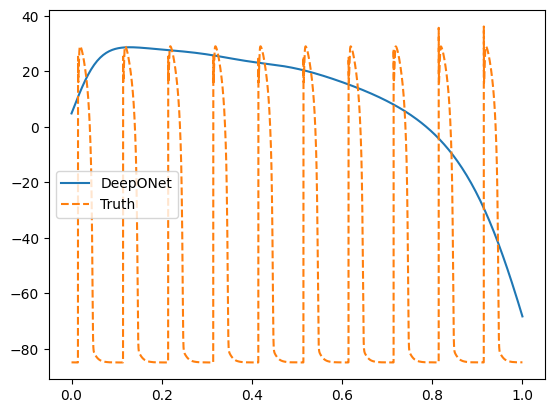

In [ ]:
# 1. Minimal DeepONet Class
class DeepONet(nn.Module):
    def __init__(self, n_params, n_basis=50):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Linear(n_params, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, n_basis)
        )
        self.trunk = nn.Sequential(
            nn.Linear(1, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, n_basis)
        )
        self.bias = nn.Parameter(torch.tensor(0.0))

    def forward(self, p, t):
        # Dot product of Branch(p) and Trunk(t)
        return torch.sum(self.branch(p) * self.trunk(t), dim=1, keepdim=True) + self.bias

# 2. Data Loading & Flattening
# Define the parameter keys you want to learn from
KEYS = list(parameters[0].keys())
data_p, data_t, data_v = [], [], []

# Assuming 'voltage' and 'parameters' dicts exist in your workspace
for k in range(-1, 100):
    if k not in voltage: continue
    APs, starting_indexes = get_AP(voltage[k])
    last_AP = APs[-1]
    # Extract & Flatten
    APD, APD_boundary = get_APD(last_AP, dt=0.2, APD_percentage=0.1)
    v_seq = last_AP[int(APD_boundary[0]):int(APD_boundary[1])]
    p_vals = [parameters[k][p] for p in KEYS]
    steps = len(v_seq)
    
    # Repeat Param for every time step; Create Time [0...1]
    data_p.append(np.tile(p_vals, (steps, 1)))
    data_t.append(np.linspace(0, 1, steps).reshape(-1, 1))
    data_v.append(np.array(v_seq).reshape(-1, 1))

# Stack
X_p = np.vstack(data_p)
X_t = np.vstack(data_t)
Y_v = np.vstack(data_v)

# Normalize Parameters (MinMax)
p_min, p_max = X_p.min(0), X_p.max(0)
X_p = (X_p - p_min) / (p_max - p_min + 1e-8)

# To Tensors
inputs_p = torch.tensor(X_p, dtype=torch.float32)
inputs_t = torch.tensor(X_t, dtype=torch.float32)
target_v = torch.tensor(Y_v, dtype=torch.float32)

# 3. Train
model = DeepONet(n_params=len(KEYS))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

print(f"Training on {len(target_v)} samples...")
for epoch in range(2000):
    optimizer.zero_grad()
    pred = model(inputs_p, inputs_t)
    loss = loss_fn(pred, target_v)
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0: print(f"Ep {epoch}: {loss.item():.5f}")



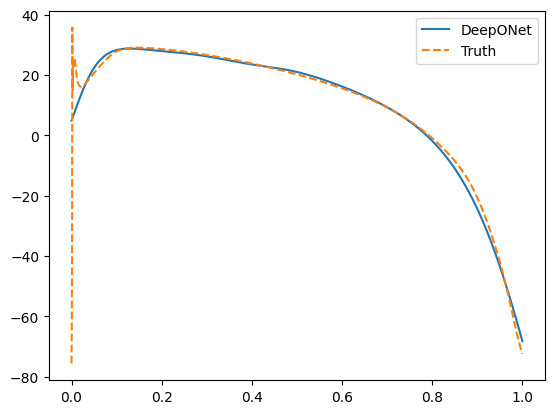

In [4]:
APs, starting_indexes = get_AP(voltage[0])
last_AP = APs[-1]
# Extract & Flatten
APD, APD_boundary = get_APD(last_AP, dt=0.2, APD_percentage=0.1)
v_seq = last_AP[int(APD_boundary[0]):int(APD_boundary[1])]
# 4. Predict (Example using key 0 parameters)
with torch.no_grad():
    # Prepare single test case
    test_p_raw = np.array([parameters[0][key] for key in KEYS])
    test_p_norm = (test_p_raw - p_min) / (p_max - p_min + 1e-8)
    
    # Create time vector 0 to 1
    t_test = torch.linspace(0, 1, 300).view(-1, 1)
    # Repeat params to match time vector length
    p_test = torch.tensor(test_p_norm, dtype=torch.float32).repeat(300, 1)
    
    pred_curve = model(p_test, t_test)

plt.plot(t_test, pred_curve, label='DeepONet')
plt.plot(np.linspace(0, 1, len(v_seq)), v_seq, label='Truth', linestyle='--')
plt.legend()
plt.show()